In [ ]:
import sqlite3
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_csv("student_performance.csv")
print(f"Dataset loaded :{df.shape[0]} students, {df.shape[1]} columns")
print(f"columns : {df.columns.to_list()}")

Dataset loaded :30 students, 13 columns
columns : ['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']


In [ ]:
conn=sqlite3.connect("college.db")

cursor=conn.cursor()

df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)

cursor.execute("SELECT COUNT(*) FROM students")

count=cursor.fetchone()[0]

print("database created")

print(f"Table'students' has {count} rows")

database created
Table'students' has 30 rows


In [ ]:
cursor.execute("PRAGMA table_info(students)")
c_info=cursor.fetchall()
print("Table structure of 'students")
print(f"{'Column Name':25} {'Data Type':<12}")
print("-" * 38)
for col in c_info:
  print(f"{col[1]:25} {col[2]:<12}")

Table structure of 'students
Column Name               Data Type   
--------------------------------------
student_id                INTEGER     
name                      TEXT        
age                       INTEGER     
gender                    TEXT        
department                TEXT        
semester                  INTEGER     
math_score                INTEGER     
science_score             INTEGER     
english_score             INTEGER     
programming_score         INTEGER     
attendance_percentage     INTEGER     
city                      TEXT        
admission_year            INTEGER     


In [ ]:
def run_query(sql,description=""):
  if description:
    print(f"\n{'='*55}")
    print(f" {description}")
    print(f"{'='*55}")
  result=pd.read_sql_query(sql,conn)
  print(result.to_string(index=False))
  return result
query1="""SELECT student_id,name,department,math_score,attendance_percentage FROM students LIMIT 10"""
result1=run_query(query1,"First 10 students(SELECT+LIMIT)\n")
result2=run_query("\nSELECT student_id,name,department,math_score,attendance_percentage FROM students ORDER BY student_id DESC LIMIT 5")



 First 10 students(SELECT+LIMIT)

 student_id         name       department  math_score  attendance_percentage
       1001 Aarav Sharma Computer Science          85                     92
       1002  Priya Patel Computer Science          76                     87
       1003  Rohit Verma      Electronics          65                     78
       1004  Sneha Reddy       Mechanical          70                     95
       1005   Arjun Nair Computer Science          92                     90
       1006  Meera Joshi      Electronics          58                     72
       1007  Kiran Kumar            Civil          73                     85
       1008  Divya Singh Computer Science          88                     96
       1009 Rahul Mishra       Mechanical          62                     68
       1010   Ananya Das Computer Science          95                     98
 student_id           name       department  math_score  attendance_percentage
       1030 Akanksha Yadav Computer Sci

In [ ]:
result3=run_query("SELECT student_id,name,department,programming_score FROM students WHERE programming_score>50 AND programming_score<75")

 student_id          name  department  programming_score
       1003   Rohit Verma Electronics                 55
       1006   Meera Joshi Electronics                 52
       1011   Vikram Iyer Electronics                 72
       1014 Kavya Nambiar  Mechanical                 51
       1016  Ritu Agarwal Electronics                 69
       1021 Harish Pillai Electronics                 58
       1024 Preeti Saxena  Mechanical                 53
       1026    Rekha Nair Electronics                 63


In [ ]:
s=run_query("SELECT  student_id,name,department,programming_score FROM students WHERE department='Computer Science' ORDER BY programming_score DESC")

 student_id           name       department  programming_score
       1010     Ananya Das Computer Science                 97
       1022    Tanvi Mehta Computer Science                 96
       1005     Arjun Nair Computer Science                 95
       1030 Akanksha Yadav Computer Science                 94
       1008    Divya Singh Computer Science                 93
       1018 Swati Kulkarni Computer Science                 92
       1001   Aarav Sharma Computer Science                 91
       1025      Amit Bose Computer Science                 89
       1013     Suresh Rao Computer Science                 88
       1027  Gaurav Shukla Computer Science                 87
       1020   Nisha Kapoor Computer Science                 83
       1002    Priya Patel Computer Science                 79
       1015    Ajay Tiwari Computer Science                 76


In [ ]:
r=run_query(" student_id,name,department,programming_score FROM students WHERE ")

DatabaseError: Execution failed on sql ' student_id,name,department,programming_score FROM students WHERE ': near "student_id": syntax error

In [ ]:
student_highest_programming_query = run_query("SELECT name, department, programming_score FROM students ORDER BY programming_score DESC LIMIT 1",description="Student with the highest programming score:")


In [ ]:
t=run_query("SELECT name,department,attendance_percentage FROM students WHERE attendance_percentage NOT BETWEEN 0 AND 85 ORDER BY attendance_percentage DESC")

In [ ]:
dept_data={
    'dept_code': ['CS','EC','ME','CE'],
    'dept_name':['Computer Science','Electronics','Mechanical','Civil'],
    'hod_name': ['Dr.Sharma' ,'Dr. Reddy','Dr. patel', 'Dr. Kumar'],
    'established': [1985,1988,1972,1965],
    'intake': [60,60,60,60]
}
dept_df=pd.DataFrame(dept_data)

In [ ]:
dept_df.to_sql('departments',conn,if_exists='replace',index=False)

print("Created 'departments' table")
print(dept_df.to_string(index=False))
dept_map={
    'Computer Science':'CS',
    'Electronics':'EC',
    'Mechanical':'ME',
    'Civil':'CE'
}
df['dept_code']=df['department'].map(dept_map)

df.to_sql('students',conn,if_exists='replace',index=False)

Created 'departments' table
dept_code        dept_name  hod_name  established  intake
       CS Computer Science Dr.Sharma         1985      60
       EC      Electronics Dr. Reddy         1988      60
       ME       Mechanical Dr. patel         1972      60
       CE            Civil Dr. Kumar         1965      60


30

In [ ]:
q=run_query("SELECT s.name,s.math_score,d.dept_name,d.hod_name,d.established FROM students AS s INNER JOIN departments d ON s.dept_code=d.dept_code ORDER BY s.math_score DESC LIMIT 8")

          name  math_score        dept_name  hod_name  established
    Ananya Das          95 Computer Science Dr.Sharma         1985
   Tanvi Mehta          93 Computer Science Dr.Sharma         1985
    Arjun Nair          92 Computer Science Dr.Sharma         1985
Akanksha Yadav          91 Computer Science Dr.Sharma         1985
Swati Kulkarni          90 Computer Science Dr.Sharma         1985
   Divya Singh          88 Computer Science Dr.Sharma         1985
  Ritu Agarwal          87      Electronics Dr. Reddy         1988
     Amit Bose          86 Computer Science Dr.Sharma         1985


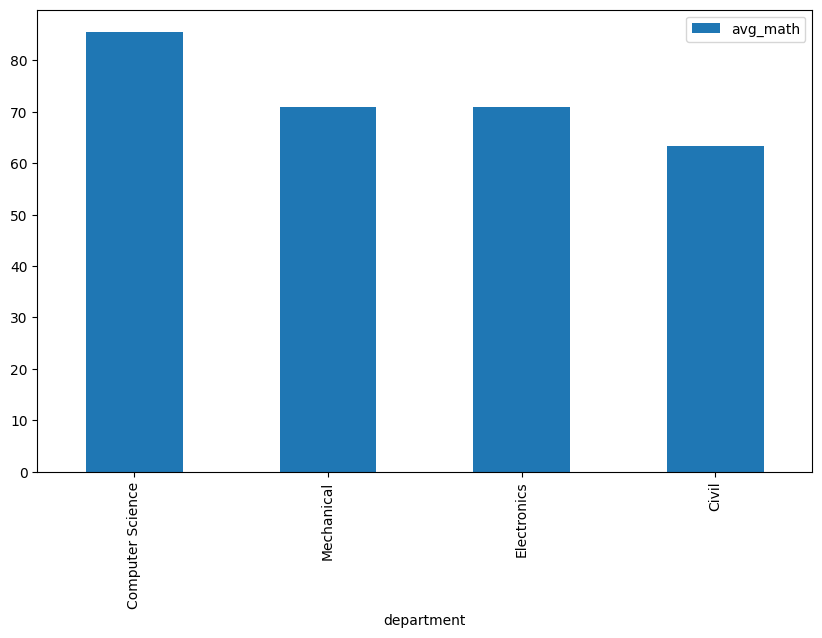

In [ ]:
chart1="""SELECT department,ROUND(AVG(math_score),2) AS avg_math FROM students GROUP BY department ORDER BY avg_math DESC"""
c_data=pd.read_sql_query(chart1,conn)
fix,ax=plt.subplots(figsize=(10,6))
bar=c_data.plot(kind='bar',x='department',y='avg_math',ax=ax)
